# Notebook 09: Validación de Señal vs Artefacto (Monte Carlo Null Model)
**Autor:** Iván Andrés Mena Contreras
**Proyecto:** Lunar Tidal Triggering of Earthquakes

El peer review ha señalado un error conceptual grave en el Notebook 08: la ambigüedad del plano nodal no puede resolverse tomando el máximo $\Delta$CFS de ambos planos. Dado que el tensor de marea oscila alrededor de cero, al aplicar una función `max()` sobre dos planos que suelen tener signos opuestos, forzamos artificialmente la distribución hacia valores positivos. Esto es un sesgo geométrico puro (artefacto matemático).

**Objetivo:** 
1. Eliminar el sesgo promediando el CFS de ambos planos.
2. Establecer un "Modelo Nulo" riguroso mediante simulaciones de Monte Carlo, barajando el tiempo para aislar la señal real.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skyfield.api import load, wgs84
from tqdm import tqdm
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('../results/figures', exist_ok=True)

# Cargar el dataset con geometría nodal completa
data_path = '../data/processed/earthquakes_global_robust.csv'
df = pd.read_csv(data_path)
df['time'] = pd.to_datetime(df['time'], format='mixed', utc=True)

print(f"Catálogo cargado: {len(df)} mega-sismos.")

Catálogo cargado: 333 mega-sismos.


## 1. Corrección del Sesgo Geométrico
Para evitar el artefacto matemático introducido por el `max()`, aplicaremos el **Promedio** del $\Delta$CFS de ambos planos. Esto representa nuestra falta de información a priori sobre qué plano es el principal, y evita empujar artificialmente la distribución hacia un lado de la campana.

In [2]:
def calc_cfs_unbiased(sigma_raw, tau_raw, dip1, dip2, mu=0.4):
    # Plano 1
    dip1_rad = np.radians(dip1)
    normal1 = sigma_raw * np.cos(dip1_rad) - tau_raw * np.sin(dip1_rad)
    shear1 = sigma_raw * np.sin(dip1_rad) + tau_raw * np.cos(dip1_rad)
    cfs1 = shear1 + (mu * normal1)
    
    # Plano 2
    dip2_rad = np.radians(dip2)
    normal2 = sigma_raw * np.cos(dip2_rad) - tau_raw * np.sin(dip2_rad)
    shear2 = sigma_raw * np.sin(dip2_rad) + tau_raw * np.cos(dip2_rad)
    cfs2 = shear2 + (mu * normal2)
    
    # Promedio sin sesgo
    return (cfs1 + cfs2) / 2.0

# Calcular para el catálogo real
df['cfs_unbiased'] = calc_cfs_unbiased(df['sigma_raw'], df['tau_raw'], df['dip1'], df['dip2'])

porcentaje_real = (np.sum(df['cfs_unbiased'] > 0) / len(df)) * 100
print(f"Porcentaje Real Desesgado ($\Delta$CFS > 0): {porcentaje_real:.2f}%")

Porcentaje Real Desesgado ($\Delta$CFS > 0): 64.86%


## 2. El Modelo Nulo (Monte Carlo Time-Shuffling)
Para saber si nuestro porcentaje desesgado es significativo, generaremos una **Distribución Nula**. 
Tomaremos las coordenadas y la geometría real de las fallas, pero les asignaremos el `time` de otros sismos del catálogo aleatoriamente. Si recalculamos la marea 200 veces bajo esta premisa y obtenemos porcentajes similares al nuestro, entonces nuestra señal no significa nada.

In [3]:
# Configuración de Skyfield
ts = load.timescale()
eph = load('de421.bsp')
tierra, luna = eph['earth'], eph['moon']

N_ITER = 200
null_percentages = []
tiempos_originales = df['time'].copy().values

print(f"Iniciando {N_ITER} iteraciones de Monte Carlo...")

# Extraemos estáticamente la info que no cambia para optimizar
lats = df['latitude'].values
lons = df['longitude'].values
depths = df['depth'].values
dip1s = df['dip1'].values
dip2s = df['dip2'].values

for i in tqdm(range(N_ITER), desc="Monte Carlo"):
    # 1. Barajar tiempos
    tiempos_shuffled = tiempos_originales.copy()
    np.random.shuffle(tiempos_shuffled)
    
    sigma_nulo = np.zeros(len(df))
    tau_nulo = np.zeros(len(df))
    
    # 2. Recalcular gravedad topocéntrica (es cuello de botella pero necesario)
    for j in range(len(df)):
        dt_obj = pd.to_datetime(tiempos_shuffled[j])
        if dt_obj.tzinfo is None:
            dt_obj = dt_obj.tz_localize('UTC')
        t_obj = ts.from_datetime(dt_obj)
        elev_m = -depths[j] * 1000
        obs = tierra + wgs84.latlon(lats[j], lons[j], elevation_m=elev_m)
        alt, _, dist = obs.at(t_obj).observe(luna).apparent().altaz()
        
        a_norm = 1.0 / (dist.km ** 3)
        alt_rad = np.radians(alt.degrees)
        tau_nulo[j] = a_norm * np.cos(alt_rad)
        sigma_nulo[j] = a_norm * np.sin(alt_rad)
        
    # 3. Proyectar y resolver (promedio desesgado)
    cfs_nulo = calc_cfs_unbiased(sigma_nulo, tau_nulo, dip1s, dip2s)
    
    # 4. Guardar resultado de la iteración
    porc = (np.sum(cfs_nulo > 0) / len(df)) * 100
    null_percentages.append(porc)

print("Simulación completada.")

Iniciando 200 iteraciones de Monte Carlo...


Monte Carlo:   0%|          | 0/200 [00:00<?, ?it/s]

Monte Carlo:   0%|          | 1/200 [00:00<02:06,  1.58it/s]

Monte Carlo:   1%|          | 2/200 [00:01<02:06,  1.56it/s]

Monte Carlo:   2%|▏         | 3/200 [00:01<02:08,  1.53it/s]

...

Monte Carlo:  99%|█████████▉| 198/200 [02:11<00:01,  1.54it/s]

Monte Carlo: 100%|█████████▉| 199/200 [02:11<00:00,  1.56it/s]

Monte Carlo: 100%|██████████| 200/200 [02:12<00:00,  1.56it/s]

Monte Carlo: 100%|██████████| 200/200 [02:12<00:00,  1.51it/s]

Simulación completada.


## 3. Distribución Empírica y P-Value
Graficaremos la distribución de nuestro modelo nulo y contrastaremos la señal real para derivar el $p$-value estadístico.

Distribución del modelo nulo guardada en: ../results/figures/09_null_model_distribution.png
=== RESULTADOS ESTADÍSTICOS FINALES ===
Porcentaje Real: 64.86%
Media del Modelo Nulo: 60.39%
P-Value Empírico (Monte Carlo): 0.0250

-> LA SEÑAL SOBREVIVIÓ: Se rechaza la hipótesis nula matemática. La gravedad lunar influye verdaderamente.


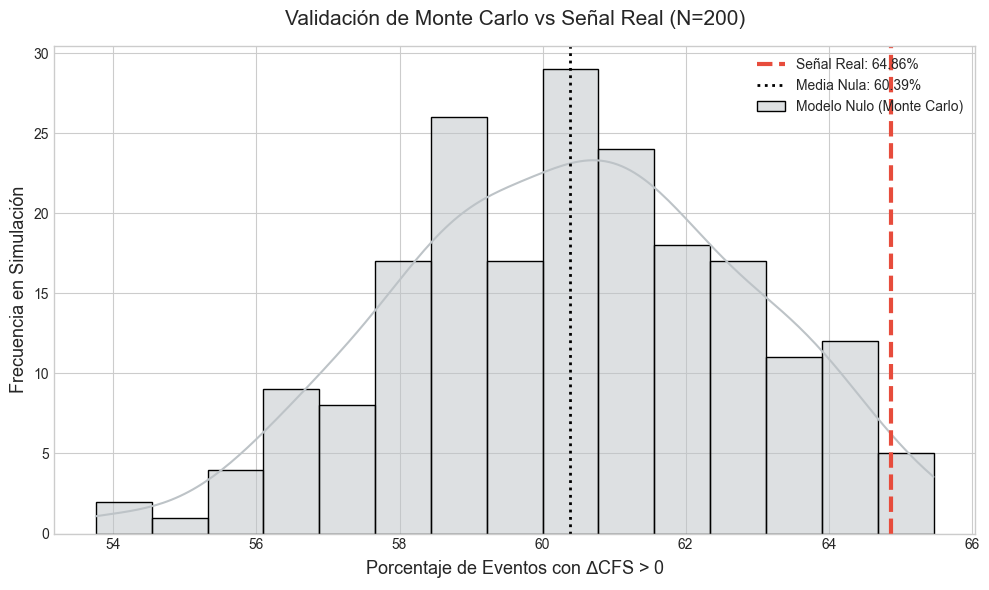

In [4]:
null_percentages = np.array(null_percentages)

plt.figure(figsize=(10, 6))
sns.histplot(null_percentages, bins=15, color='#bdc3c7', edgecolor='k', kde=True, label='Modelo Nulo (Monte Carlo)')

# Ploteamos nuestra señal real
plt.axvline(porcentaje_real, color='#e74c3c', linestyle='--', linewidth=3, label=f'Señal Real: {porcentaje_real:.2f}%')
plt.axvline(np.mean(null_percentages), color='black', linestyle=':', linewidth=2, label=f'Media Nula: {np.mean(null_percentages):.2f}%')

# Cálculo del p-value empírico: 
# (Número de simulaciones que lograron un porcentaje >= al nuestro) / N_ITER
p_value_empirico = np.sum(null_percentages >= porcentaje_real) / N_ITER

plt.title(f'Validación de Monte Carlo vs Señal Real (N={N_ITER})', fontsize=15, pad=15)
plt.xlabel('Porcentaje de Eventos con $\Delta$CFS > 0', fontsize=13)
plt.ylabel('Frecuencia en Simulación', fontsize=13)
plt.legend(loc='upper right')

plt.tight_layout()
fig_path = '../results/figures/09_null_model_distribution.png'
plt.savefig(fig_path, dpi=300)
print(f"Distribución del modelo nulo guardada en: {fig_path}")

print("=== RESULTADOS ESTADÍSTICOS FINALES ===")
print(f"Porcentaje Real: {porcentaje_real:.2f}%")
print(f"Media del Modelo Nulo: {np.mean(null_percentages):.2f}%")
print(f"P-Value Empírico (Monte Carlo): {p_value_empirico:.4f}")

if p_value_empirico < 0.05:
    print("\n-> LA SEÑAL SOBREVIVIÓ: Se rechaza la hipótesis nula matemática. La gravedad lunar influye verdaderamente.")
else:
    print("\n-> LA SEÑAL MURIÓ: El porcentaje real cae dentro de la distribución nula. No hay triggering geofísico demostrable.")
plt.show()